In [26]:
# CELL 0 - Load data and set up analysis switches
from pathlib import Path
import fusiproc_utils2 as fu
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
from nilearn.glm.first_level import FirstLevelModel
from nilearn import plotting, image

# -------- dataset paths -------
BASE = Path('/Users/clairenastaskin/data/sub-Forest002/ses-20260215/task_audio_ARIA')
RUN  = 'bbc3_pwd.nii.gz'
PWD  = BASE / RUN

# -------- analysis switches ----
CONF_USE = dict(
    motion_6      = False,     # translation/rotation 6 params
    motion_fsl24  = True,    # Friston24 (mutually exclusive with motion_6)
    extra_fd      = False,
    dvars_stdz    = False,
    tcompcor      = False,
)

# --- temporal smoothing ------------------------------------------------------
SMOOTH_METHOD  = "boxcar"          # {"none", "boxcar", "savgol"}
SMOOTH_WINDOW  = 3                 # for boxcar (odd)
SG_PARAMS      = dict(window=7, polyorder=2)       # Savitzky–Golay (odd) 

FD_THRESH     = 0.25          # mm
RADIUS_MM     = 50.0         # mm for FD sphere

# ---------------------------------------------------------------------------
# Build a short suffix that encodes the chosen method (+ key params)
# ---------------------------------------------------------------------------
if SMOOTH_METHOD == "none":
    smooth_tag = "_nosmooth"

elif SMOOTH_METHOD == "boxcar":
    smooth_tag = f"_boxcar{SMOOTH_WINDOW}"

elif SMOOTH_METHOD == "savgol":
    smooth_tag = f"_savgol{SG_PARAMS['window']}-{SG_PARAMS['polyorder']}"

else:
    raise ValueError(f"Unknown SMOOTH_METHOD: {SMOOTH_METHOD}")


In [27]:
# CELL 1 - Mean image
from nilearn import image

# Select only the first 240 volumes before computing the mean
img_subset = image.mean_img(PWD)
mean_img = image.mean_img(img_subset)  
mean_path = BASE / RUN.replace('_pwd.nii.gz', '_mean.nii.gz')
mean_img.to_filename(mean_path)
print(f"Mean image saved to {mean_path}")

/var/folders/50/vlgy95sd2d1d6w1_l8pgqd1c0000gn/T/ipykernel_26793/3929620160.py:5: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  img_subset = image.mean_img(PWD)


Mean image saved to /Users/clairenastaskin/data/sub-Forest002/ses-20260215/task_audio_ARIA/bbc3_mean.nii.gz


/var/folders/50/vlgy95sd2d1d6w1_l8pgqd1c0000gn/T/ipykernel_26793/3929620160.py:6: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  mean_img = image.mean_img(img_subset)


In [28]:
# Load ARIA logs and convert to numpy array, then save as JSON
logs_path = Path('/Users/clairenastaskin/data/sub-Forest001/2026-02-03/ARIA_data/logs.parquet')
logs_df = pd.read_parquet(logs_path)
logs_arr = logs_df.to_numpy()

# Save as JSON: each column becomes a key, its values become the array
json_out = logs_path.with_suffix('.json')
logs_df.to_json(json_out, orient='columns', indent=2)
print(f"Saved JSON to {json_out}")

print(f"Loaded {logs_path.name}: shape {logs_df.shape}, columns: {list(logs_df.columns)}")
logs_arr

Saved JSON to /Users/clairenastaskin/data/sub-Forest001/2026-02-03/ARIA_data/logs.json
Loaded logs.parquet: shape (270, 14), columns: ['time_ns', 'perfcounter_ns', 'monotonic_ns', 'VDDA', 'VDDD', 'VREFP', 'VREFM', 'VDD5', 'VDDHV', 'VBIAS', 'VNEGHV', 'VBAT', 'BAT_TEMP', 'INTERPOSER_TEMP']


array([[1.77016136e+18, 9.67683394e+12, 9.67683394e+12, ...,
        3.75000000e+00, 3.69999924e+01, 2.97500000e+01],
       [1.77016136e+18, 9.67844254e+12, 9.67844254e+12, ...,
        3.75000000e+00, 3.69999924e+01, 3.00000000e+01],
       [1.77016136e+18, 9.68004286e+12, 9.68004286e+12, ...,
        3.75000000e+00, 3.69999924e+01, 3.03125000e+01],
       ...,
       [1.77016179e+18, 1.01050588e+13, 1.01050588e+13, ...,
        3.75000000e+00, 3.69999924e+01, 4.10625000e+01],
       [1.77016179e+18, 1.01066711e+13, 1.01066711e+13, ...,
        3.75000000e+00, 3.69999924e+01, 4.10625000e+01],
       [1.77016179e+18, 1.01082945e+13, 1.01082945e+13, ...,
        3.75000000e+00, 3.69999924e+01, 4.10625000e+01]])

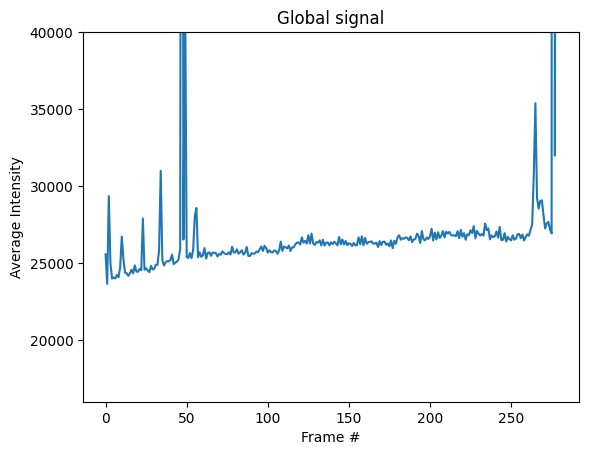

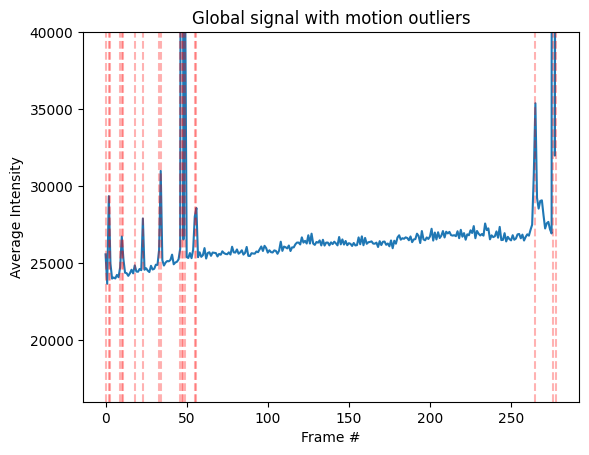

In [29]:
# CELL 2 - Global signal and motion detection
data, affine, _ = fu.load_fusi_nifti(PWD)
mask = fu.nan_mask(data)
mask_path = fu.save_nifti(mask.astype(np.uint8), affine,
                          PWD.with_name(RUN.replace('_pwd', '_mask')))

y_lim= (1.6e4, 4e4) # If we want to set the y-axis limits

gs = fu.global_signal(data)
fu.plot_global_signal(gs, BASE/"global_signal.png",y_lim)
import matplotlib.pyplot as plt

SIDE = BASE / 'logs.json'
TR = (SIDE)
np.save(BASE / "t_r.npy", TR)
bad_gs, good_gs, fig = fu.detect_motion_via_global(gs, TR, k = 1.4, y_lim=y_lim)
fig.savefig(BASE/"global_signal_with_masked_frame.png")
skip = set(bad_gs)

In [30]:
# CELL 4 - Rigid registration
# ------------------------------------------------------------------
# Rigid registration
# ------------------------------------------------------------------
registration_path = BASE / "registration"

if not registration_path.exists():
    registration_path.mkdir(exist_ok=True)
    
    reg, rigid, metric, stop, kept_idx = fu.register_3d_image_stack(
            np.where(np.isfinite(data), data, 0),
            reference='median',
            spacing=np.linalg.norm(affine[:3, :3], axis=0),
            skip_indices=skip,
            mask=mask,
            verbose=True)

    # Save the registration outputs
    np.save(registration_path / "reg.npy", reg)
    np.save(registration_path / "rigid.npy", rigid)
    np.save(registration_path / "metric.npy", metric)
    np.save(registration_path / "stop.npy", stop)
    np.save(registration_path / "kept_idx.npy", kept_idx)
    np.save(registration_path / "skip.npy", skip)
    # ---- Doppler movie -------------------------------------------------
    html = fu.save_doppler_movie(reg, registration_path/"Doppler_movie_after_rigid_registration.mp4")
    html  # renders in Jupyter

else:
    reg = np.load(registration_path / "reg.npy")
    rigid = np.load(registration_path / "rigid.npy")
    metric = np.load(registration_path / "metric.npy")
    stop = np.load(registration_path / "stop.npy")
    kept_idx = np.load(registration_path / "kept_idx.npy")



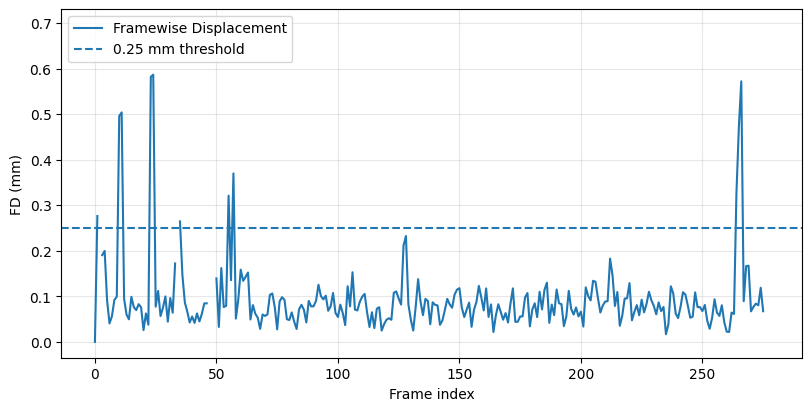

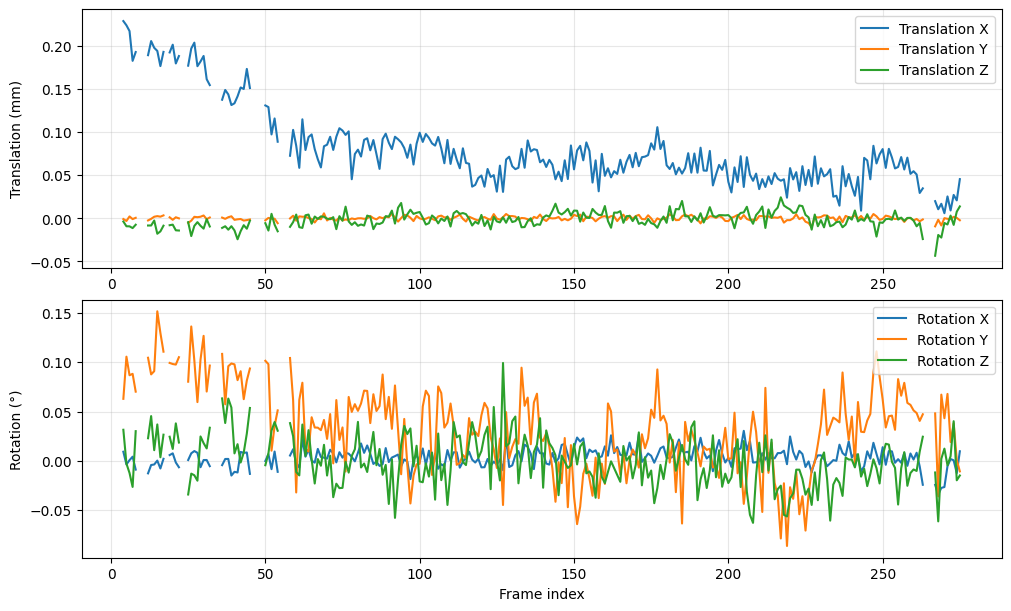

In [31]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 5 – FD outliers, censor list, NaN‑padding
# ─────────────────────────────────────────────────────────────────────────────
n_frames = data.shape[-1]

# 1. FD on the gap‑free series (after GS censoring) ---------------------------
fd = fu.framewise_displacement(rigid, radius_mm=RADIUS_MM)

fd_full = np.full(n_frames, np.nan)
fd_full[kept_idx] = fd

bad_fd = fu.plot_fd(fd_full, FD_THRESH, BASE/"framewise_displacement.png")
np.savetxt(BASE/"fd_over_0p5_indices.txt", bad_fd, fmt='%d')

# 2. update global censor list ------------------------------------------------
skip.update(int(i) for i in bad_fd)

# 3. remove newly censored frames from the registration outputs ---------------
keep_after_all = [i for i in kept_idx if i not in skip]     # T indices
sel            = np.isin(kept_idx, keep_after_all)          # boolean mask

reg_use    = reg[...,  sel]           # (x,y,z,T)
rigid_use  = rigid[:,  sel]           # (6,T)
metric_use = metric[   sel]           # (T,)
stop_use   = [s for s, ok in zip(stop, sel) if ok]

# 4. create full‑length NaN‑padded arrays ------------------------------------
retained = keep_after_all                                 # same T indices
reg_full, rigid_full, metric_full, stop_full = fu.reinstate_nans(
        reg_use, rigid_use, metric_use, stop_use,
        n_frames, retained)

fu.plot_registration_parameters(rigid_full, registration_path/"registration.png")


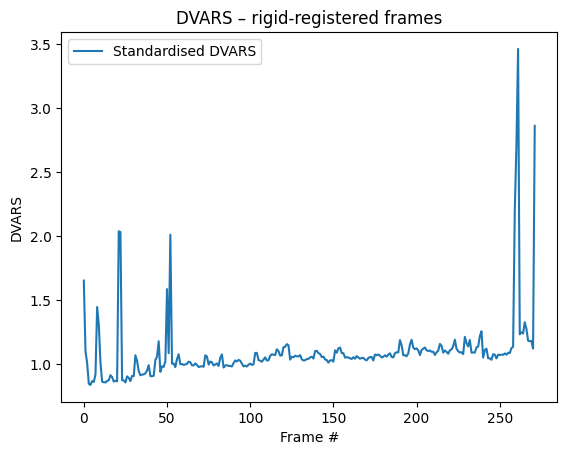

In [32]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 6 – DVARS calculation and temporal CompCor (tCompCor) confounds
# ─────────────────────────────────────────────────────────────────────────────

# Save rigid registered data (after registration, before smoothing) as a Nifti file
reg_path = fu.save_nifti(reg.astype(np.float32), affine,
                         BASE/"fusi_data_rigid_reg.nii.gz")

# Calculate standardized DVARS, raw DVARS, and voxelwise DVARS from the registered Nifti
dvars_stdz, dvars_raw, dvars_vx = fu.calc_dvars(reg_path, mask_path)

# Plot the standardized DVARS with marked motion outliers
fu.plot_dvars(dvars_stdz, BASE/"dvars_rigid.png")

# Run tCompCor (temporal CompCor) if selected in configuration.
# This extracts confound timecourses from noise ROIs in the data for denoising.
tc_out = {}
if CONF_USE["tcompcor"]:
    tc_out = fu.run_tcompcor(reg_path, mask_path,
                             BASE/"confounds", n_components=6,
                             percentile_threshold=0.02, tr=TR)

In [33]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 7 – sample mask, temporal smoothing, confounds (length‑matched)
# ─────────────────────────────────────────────────────────────────────────────
good_all    = np.array(retained, dtype=int)   # final list of frames to keep
sample_mask = good_all                        # passed to Nilearn

# -- temporal smoothing -------------------------------------------------------
if   SMOOTH_METHOD == "none":
    smoothed = reg_f
    ull.copy()

elif SMOOTH_METHOD == "boxcar":
    # Apply boxcar (moving average) smoothing: replaces each frame with the average across a sliding window.
    smoothed = fu.boxcar_smooth(reg_full, SMOOTH_WINDOW)

elif SMOOTH_METHOD == "savgol":
    # Apply Savitzky-Golay filter (polynomial smoothing filter). This method smooths the data
    # by fitting successive sub-sets of adjacent frames with a low-degree polynomial.
    smoothed = fu.savgol_smooth(reg_full, **SG_PARAMS)


else:
    raise ValueError(f"Unknown SMOOTH_METHOD “{SMOOTH_METHOD}”")

clean_img = nib.Nifti1Image(np.nan_to_num(smoothed), affine)
clean_img.to_filename(BASE/"fusi_run_clean.nii.gz")

# ------------------------------------------------------------------
# Build confounds – all arrays must have n_frames rows
# ------------------------------------------------------------------
conf_list = []

# ── Motion regressors ──────────────────────────────────────────────────────
motion_full = rigid_full.T.copy()          # (n_frames, 6) – tx,ty,tz,rotx,roty,rotz
motion_full[np.isnan(motion_full)] = 0

if CONF_USE["motion_fsl24"]:
    # --- FSL‑24 construction ---
    # Compute first derivative of motion parameters (frame-to-frame changes)
    deriv = np.vstack([np.zeros((1, 6)), np.diff(motion_full, axis=0)])
    # Compute quadratic terms (squares of parameters and derivatives)
    quad  = np.square(np.hstack([motion_full, deriv]))      # 12 quadratic terms

    # Concatenate original parameters, derivatives, and all quadratic terms to obtain 24 regressors
    fsl24 = np.hstack([motion_full, deriv, quad])           # 6 + 6 + 12 = 24
    labels = (
        [f"{p}"   for p in ("tx","ty","tz","rotx","roty","rotz")] +
        [f"d{p}"  for p in ("tx","ty","tz","rotx","roty","rotz")] +
        [f"{p}2"  for p in ("tx","ty","tz","rotx","roty","rotz")] +
        [f"d{p}2" for p in ("tx","ty","tz","rotx","roty","rotz")]
    )
    # Package FSL-24 regressors into DataFrame
    conf_list.append(pd.DataFrame(fsl24, columns=labels))

elif CONF_USE["motion_6"]:
    # Use original 6 motion parameters as regressors (translations and rotations)
    conf_list.append(pd.DataFrame(
        motion_full,
        columns=["tx", "ty", "tz", "rotx", "roty", "rotz"]
    ))
    
# Frame-wise displacement (FD): Measures the sum of absolute values of the differentiated realignment estimates. 
# Commonly used to identify volumes with excessive head motion.
if CONF_USE["extra_fd"]:
    fd_col = fd_full.copy()                   # already n_frames long
    fd_col[np.isnan(fd_col)] = 0              # replace any NaNs with 0
    conf_list.append(pd.DataFrame(fd_col, columns=["fd"]))

# DVARS (D temporal derivative VARiance): Measures the root mean square variance of the temporal derivative of each brain volume; 
# used to identify signal changes due to motion or signal artifacts.

if CONF_USE["dvars_stdz"]:
    dvars_full = np.full(n_frames, np.nan)
    dvars_full[kept_idx] = dvars_stdz         # use kept_idx (not retained_gs)
    dvars_full[np.isnan(dvars_full)] = 0      # replace any NaNs with 0
    conf_list.append(pd.DataFrame(dvars_full, columns=["dvars"]))

# tCompCor (temporal CompCor): Principal component analysis of noise regions (usually WM/CSF) for nuisance regression; 
# helps remove physiological or other noise that is not head motion.

if CONF_USE["tcompcor"]:
    comps = pd.read_csv(tc_out["components"], sep="\t").to_numpy()
    tcomp_full = np.full((n_frames, comps.shape[1]), 0.0)
    tcomp_full[kept_idx] = comps              # align with same time base
    conf_list.append(pd.DataFrame(
        tcomp_full, columns=[f"tCompCor{i:02d}" for i in range(comps.shape[1])]))


# -- final dataframe -----------------------------------------------------------
confounds_df = pd.concat(conf_list, axis=1)

/Users/clairenastaskin/Documents/Anise/Experiments/fusiproc_utils2.py:343: RuntimeWarning: Mean of empty slice
  out[..., t] = np.nanmean(data[..., lo:hi], axis=3)


In [34]:
import pandas as pd
import os

if os.path.exists(BASE / 'task_events.tsv'):
    events = pd.read_csv(BASE/"task_events.tsv", sep='\t')
else:
    task_path = list(BASE.glob('*events.tsv'))[0]
    events = pd.read_csv(task_path, sep='\t')

# events = pd.read_csv(BASE/"task_events.tsv", sep='\t')
events["trial_type"]

0     silent
1     speech
2     silent
3      audio
4     silent
5     speech
6     silent
7      audio
8     silent
9     speech
10    silent
11    speech
12    silent
13     audio
14    silent
15    speech
16    silent
17     audio
18    silent
19    speech
20    silent
21     audio
22    silent
23     audio
24    silent
Name: trial_type, dtype: object

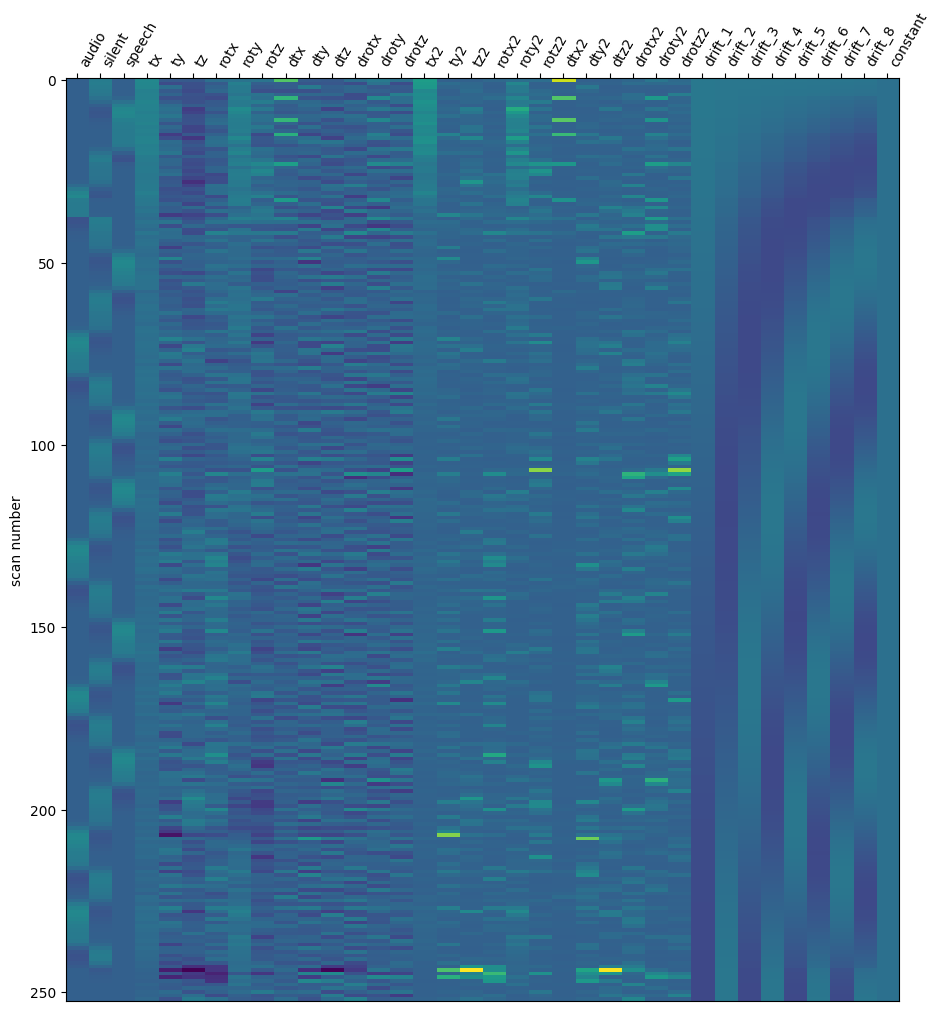

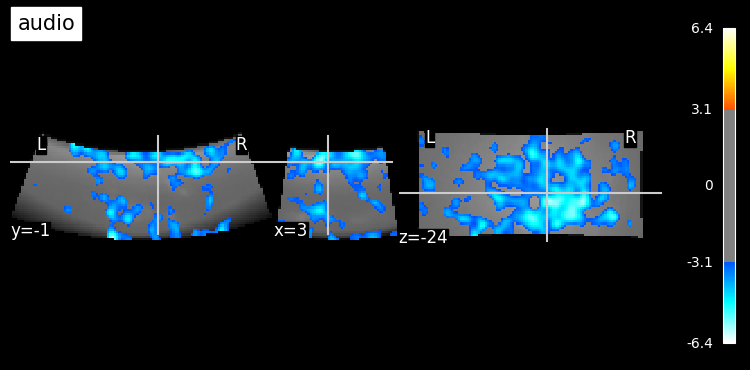

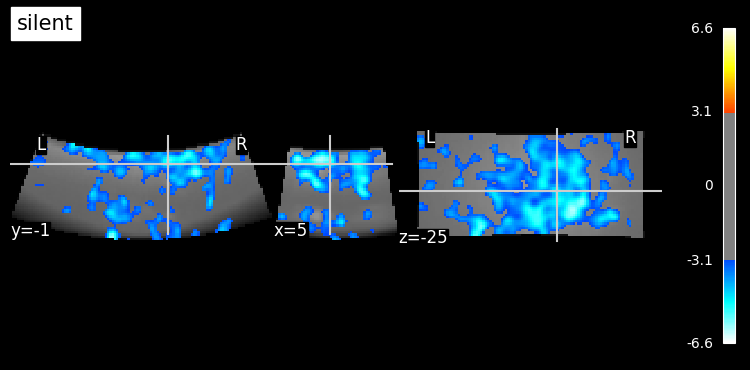

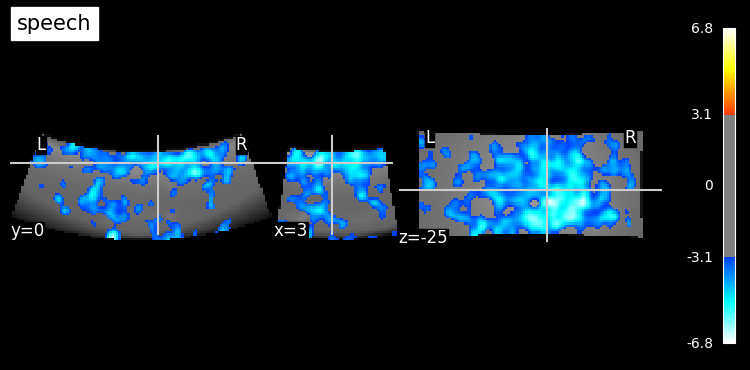

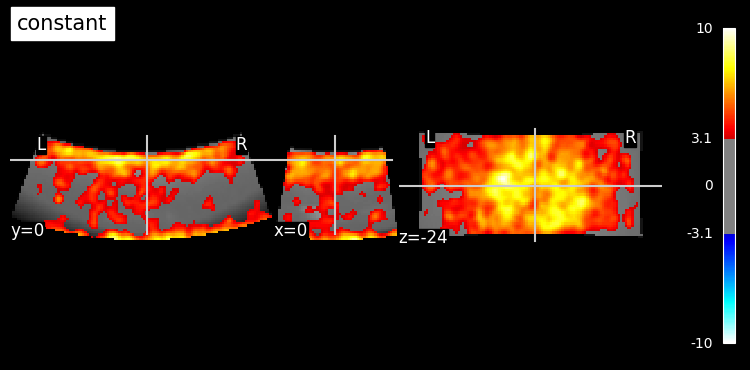

In [35]:
import json

reaction_time = 0.5  # typical reaction time assumed
with open(SIDE, 'r') as f:
    sidecar = json.load(f)


if os.path.exists(BASE / 'task_events.tsv'):
    events = pd.read_csv(BASE/"task_events.tsv", sep='\t')
else:
    task_path = list(BASE.glob('*events.tsv'))[0]
    events = pd.read_csv(task_path, sep='\t')
 
volume_timing_ns = sidecar["time_ns"]["3"] -  sidecar["time_ns"]["2"]
volume_timing_s = volume_timing_ns / 1e9
events["onset"] -= volume_timing_s
events["onset"] += reaction_time

glm = FirstLevelModel(
        t_r=volume_timing_s, hrf_model="glover", drift_model="cosine",
        high_pass=0.01, noise_model="ar1", standardize=True,
        smoothing_fwhm=2, mask_img=nib.Nifti1Image(mask.astype(np.uint8), affine))
glm.subject_data_ = clean_img
glm, design = fu.build_design_matrix(glm, events, confounds_df, sample_mask)
plotting.plot_design_matrix(design)
# Save design matrix to npz file
np.savez(BASE / "design_matrix.npz", design_matrix=design.values, column_names=design.columns)

contrasts = fu.localizer_contrasts(design)


mean_img = image.mean_img(clean_img, copy_header=True)

for name, vec in contrasts.items():
    if name.startswith(("drift_", "tx", "ty", "tz", "rot", "dt", "drot")):
        continue

    zmap = glm.compute_contrast(vec, output_type="z_score")

    # ----- build filenames ---------------------------------------------------
    stem = f"{name}{smooth_tag}_z_map"
    nii_out  = BASE / f"{stem}.nii.gz"
    png_out  = BASE / f"{stem}.png"
    # ------------------------------------------------------------------------

    zmap.to_filename(nii_out)
    plotting.plot_stat_map(
        zmap, bg_img=mean_img, threshold=3.1, display_mode="ortho",
        cut_coords=plotting.find_xyz_cut_coords(zmap, activation_threshold=3.1),
        black_bg=True, title=name
    ).savefig(png_out, dpi=300)

    plotting.show()

